In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants, units as u

from imf.cmf import hc13_mf

In [2]:
masses = np.logspace(-2,2,100) * u.M_sun

In [3]:
sizescales = np.array([0.5,2,5,20]) * u.pc
labels = ['R = 0.5 pc',
          'R = 2 pc',
          'R = 5 pc',
          'R = 20 pc']

In [57]:
cmfs = []
for scale in sizescales:
    cmfs.append((hc13_mf(masses,scale)).decompose())
cmfs = np.array(cmfs)

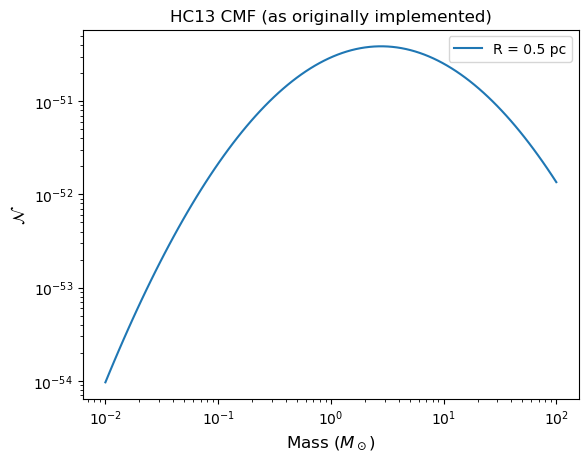

In [58]:
plt.figure()
plt.plot(masses,cmfs[0],label=labels[0])
plt.xscale('log')
plt.yscale('log')

plt.title(r'HC13 CMF (as originally implemented)')
plt.xlabel(r'Mass ($M_\odot$)',fontsize='large')
plt.ylabel(r'$\mathcal{N}$',fontsize='large')
plt.legend()

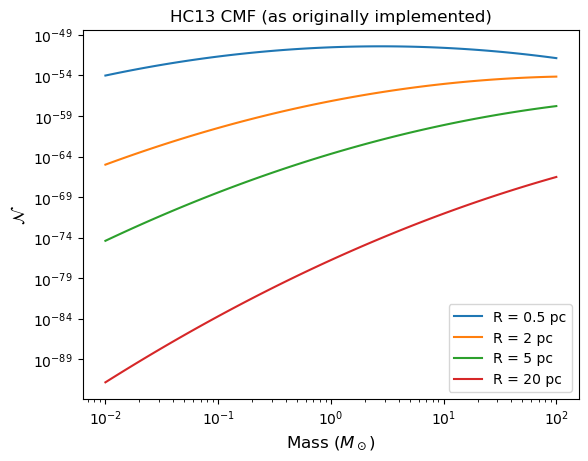

In [59]:
plt.figure()
plt.plot(masses,cmfs.T,label=labels)
plt.xscale('log')
plt.yscale('log')

plt.title(r'HC13 CMF (as originally implemented)')
plt.xlabel(r'Mass ($M_\odot$)',fontsize='large')
plt.ylabel(r'$\mathcal{N}$',fontsize='large')
plt.legend()

In [29]:
n17 = 3.8
alpha_ct = 0.75
mean_mol_wt = 2.33
V0=0.8 * u.km / u.s
meandens = 5e3 / u.cm**3
temperature = 10 * u.K
eta = 0.45
b_forcing = 0.4
Mach = 6

In [30]:
rho_bar = meandens * mean_mol_wt * constants.m_p

In [31]:
c_s = ((constants.k_B * temperature /
        (mean_mol_wt*constants.m_p))**0.5).to(u.km/u.s)

In [32]:
sig0_sq = np.log(1+b_forcing**2 * Mach**2)

In [33]:
alpha_g = 3. / 5
phi_t = 2 * alpha_ct * np.sqrt(24 / alpha_g / np.pi**2)

In [34]:
a_j = np.pi**(5/2) / 6
C_m = 4 * np.pi / 3

In [35]:
M_j = (a_j / C_m * c_s**3 / np.sqrt(constants.G**3 * rho_bar)).to(u.M_sun)

In [36]:
M_j

<Quantity 0.96973448 solMass>

In [37]:
M_twid = (masses / M_j).decompose()

In [38]:
M_twid

<Quantity [1.03121011e-02, 1.13175183e-02, 1.24209623e-02, 1.36319908e-02,
           1.49610931e-02, 1.64197812e-02, 1.80206896e-02, 1.97776846e-02,
           2.17059844e-02, 2.38222911e-02, 2.61449351e-02, 2.86940340e-02,
           3.14916669e-02, 3.45620655e-02, 3.79318242e-02, 4.16301303e-02,
           4.56890166e-02, 5.01436393e-02, 5.50325822e-02, 6.03981911e-02,
           6.62869401e-02, 7.27498350e-02, 7.98428541e-02, 8.76274338e-02,
           9.61710004e-02, 1.05547554e-01, 1.15838310e-01, 1.27132403e-01,
           1.39527655e-01, 1.53131429e-01, 1.68061554e-01, 1.84447348e-01,
           2.02430737e-01, 2.22167484e-01, 2.43828540e-01, 2.67601521e-01,
           2.93692339e-01, 3.22326980e-01, 3.53753462e-01, 3.88243988e-01,
           4.26097298e-01, 4.67641258e-01, 5.13235704e-01, 5.63275551e-01,
           6.18194222e-01, 6.78467396e-01, 7.44617129e-01, 8.17216380e-01,
           8.96893968e-01, 9.84340023e-01, 1.08031196e+00, 1.18564104e+00,
           1.30123958e+00

In [39]:
L_j = ((np.pi**(3/2) / C_m)**(1/3) * c_s / np.sqrt(constants.G * rho_bar)).to(u.pc)

In [40]:
L_j

<Quantity 0.18597801 pc>

In [41]:
R_twid = (0.5 * u.pc / L_j).decompose()

In [42]:
Mach_rel = V0 / c_s * (L_j.value)**eta / np.sqrt(3)

In [43]:
Mach_rel

<Quantity 1.15112448>

In [44]:
L_i = (Mach / Mach_rel / np.sqrt(3))**(1 / eta) * L_j

In [45]:
sigma = sig0_sq * (1 - (0.5 * u.pc / L_i)**(n17 - 3))

In [46]:
term1 = 2 / phi_t * rho_bar / M_j / R_twid**6
term2 = (1 + (1 - eta) * Mach_rel**2 * R_twid**(2*eta)) 
term3 = (1 + (2 * eta + 1) * Mach_rel**2 * R_twid**(2*eta))
term4 = (M_twid / R_twid**3)**(-1 - np.log(M_twid / R_twid**3) / 2 / sigma)
term5 = np.exp(-sigma / 8) / np.sqrt(2 * np.pi * sigma)

In [50]:
N = (term1 * term2 / term3 * term4 * term5 * (L_i)**3).decompose()

In [51]:
N

<Quantity [4.65805400e-07, 7.20848253e-07, 1.10822426e-06, 1.69260618e-06,
           2.56819895e-06, 3.87120238e-06, 5.79705683e-06, 8.62409852e-06,
           1.27457187e-05, 1.87136896e-05, 2.72959984e-05, 3.95533266e-05,
           5.69392204e-05, 8.14300101e-05, 1.15691627e-04, 1.63291599e-04,
           2.28965592e-04, 3.18948876e-04, 4.41383808e-04, 6.06814834e-04,
           8.28782268e-04, 1.12452517e-03, 1.51580168e-03, 2.02983182e-03,
           2.70036331e-03, 3.56885423e-03, 4.68575839e-03, 6.11188880e-03,
           7.91982282e-03, 1.01952988e-02, 1.30385387e-02, 1.65654162e-02,
           2.09083737e-02, 2.62169778e-02, 3.26579912e-02, 4.04148322e-02,
           4.96862892e-02, 6.06843654e-02, 7.36311421e-02, 8.87545710e-02,
           1.06283144e-01, 1.26439428e-01, 1.49432522e-01, 1.75449526e-01,
           2.04646226e-01, 2.37137236e-01, 2.72985912e-01, 3.12194457e-01,
           3.54694627e-01, 4.00339556e-01, 4.48897168e-01, 5.00045701e-01,
           5.53371770e-01

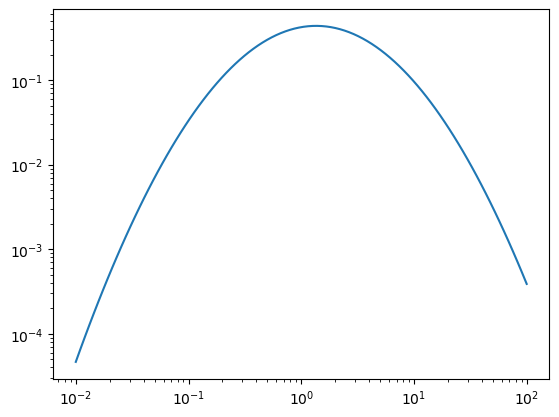

In [56]:
plt.figure()
plt.plot(masses,N/masses)
plt.xscale('log')
plt.yscale('log')